# Bundesliga past positions

**Goals:**

- Grabbing data of teams who played in Europe (UCL, UEL, UECL from 2021) & relegation zone.
- Ignoring Bayern München, Borussia Dortmund, Leipzig, and Bayer Leverkusen.
- A line chart of past positions for all teams who have played in Europe.
- Potential scatter points for...something.


## Imports


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

# Change dpi to 300
rcParams["savefig.dpi"] = 300

In [74]:
# Load fonts
compasseRegular = fm.FontProperties(fname="./Compasse Regular.ttf")
robotoLight = fm.FontProperties(fname="./Roboto-Light.ttf")
robotoRegular = fm.FontProperties(fname="./Roboto-Regular.ttf")
robotoBold = fm.FontProperties(fname="./Roboto-Bold.ttf")

## Data


In [75]:
file_path = "./Data/Past positions/"
files_list = [
    "2008-09.csv",
    "2009-10.csv",
    "2010-11.csv",
    "2011-12.csv",
    "2012-13.csv",
    "2013-14.csv",
    "2014-15.csv",
    "2015-16.csv",
    "2016-17.csv",
    "2017-18.csv",
    "2018-19.csv",
    "2019-20.csv",
    "2020-21.csv",
    "2021-22.csv",
    "2022-23.csv",
    "2023-24.csv",
    "2024-25.csv",
]

In [129]:
# Empty df to store all teams that qualified for European competitions
all_europe_teams = pd.DataFrame(
    columns=["Season", "Pos", "Team", "Pts", "Qualification or relegation"]
)

for file in files_list:
    # Ignore current season
    if file == "2024-25.csv":
        continue

    # Open the file
    league_table = pd.read_csv(file_path + file, delimiter=",", encoding="utf-8")

    # Retain relevant columns
    league_table = league_table[["Pos", "Team", "Pts", "Qualification or relegation"]]

    # Remove teams
    league_table = league_table.loc[
        (league_table["Team"] != "Bayern Munich")
        & (league_table["Team"] != "Borussia Dortmund")
        & (league_table["Team"] != "Bayer Leverkusen")
        & (league_table["Team"] != "RB Leipzig")
        & (league_table["Team"] != "VfL Wolfsburg")
        & (league_table["Team"] != "Borussia Mönchengladbach")
        & (league_table["Team"] != "Schalke 04")
    ]

    # Empty df to store teams that qualified for European competitions
    europe_teams = pd.DataFrame(
        columns=["Season", "Pos", "Team", "Pts", "Qualification or relegation"]
    )

    # Get teams that qualified for European competitions
    europe_teams = league_table.loc[
        (league_table["Qualification or relegation"].str.contains("Champions League"))
        | (league_table["Qualification or relegation"].str.contains("Europa League"))
        | (
            league_table["Qualification or relegation"].str.contains(
                "Europa Conference League"
            )
        )
        | (
            league_table["Qualification or relegation"].str.contains(
                "Conference League"
            )
        )
    ]

    # Add season column
    europe_teams = europe_teams.assign(Season=file.split(".")[0])

    # Add to all_europe_teams
    all_europe_teams = pd.concat([all_europe_teams, europe_teams], ignore_index=True)

# Remove duplicates
all_europe_teams = all_europe_teams.drop_duplicates().reset_index(drop=True)

all_europe_teams.head(10)

,Season,Pos,Team,Pts,Qualification or relegation
0,2008-09,3,VfB Stuttgart,64,Qualification to Champions League play-off round
1,2008-09,4,Hertha BSC,63,Qualification to Europa League play-off round
2,2008-09,5,Hamburger SV,61,Qualification to Europa League third qualifyin...
3,2008-09,10,Werder Bremen,45,Qualification to Europa League play-off round
4,2009-10,3,Werder Bremen,61,Qualification to Champions League play-off round
5,2009-10,6,VfB Stuttgart,55,Qualification to Europa League third qualifyin...
6,2010-11,4,Hannover 96,60,Qualification to Europa League play-off round
7,2010-11,5,Mainz 05,58,Qualification to Europa League third qualifyin...
8,2011-12,6,VfB Stuttgart,53,Qualification to Europa League play-off round
9,2011-12,7,Hannover 96,48,Qualification to Europa League third qualifyin...


In [130]:
# Get unique teams
unique_teams = all_europe_teams["Team"].unique().tolist()

# Create a matrix to store past positions
europe_matrix = pd.DataFrame(
    columns=all_europe_teams["Season"].unique().tolist() + ["2024-25"],
    index=unique_teams,
)
# Sort the teams
europe_matrix = europe_matrix.sort_index()

# Fill the matrix with seasons in Europe
for index, row in all_europe_teams.iterrows():
    europe_matrix.at[row["Team"], row["Season"]] = row["Pos"]

In [131]:
# Loop through all files and fill the rest of the matrix
for file in files_list:
    # Open the file
    league_table = pd.read_csv(file_path + file, delimiter=",", encoding="utf-8")

    # Retain relevant columns
    league_table = league_table[["Pos", "Team", "Pts", "Qualification or relegation"]]

    # Remove teams
    league_table = league_table.loc[
        (league_table["Team"] != "Bayern Munich")
        & (league_table["Team"] != "Borussia Dortmund")
        & (league_table["Team"] != "Bayer Leverkusen")
        & (league_table["Team"] != "RB Leipzig")
        & (league_table["Team"] != "VfL Wolfsburg")
        & (league_table["Team"] != "Borussia Mönchengladbach")
        & (league_table["Team"] != "Schalke 04")
    ]

    # Add season column
    league_table = league_table.assign(Season=file.split(".")[0])

    # If the team is not in the unique_teams list, skip
    for index, row in league_table.iterrows():
        if row["Team"] not in unique_teams:
            continue
        if pd.isnull(europe_matrix.at[row["Team"], row["Season"]]):
            europe_matrix.at[row["Team"], row["Season"]] = row["Pos"]

In [132]:
europe_matrix

,2008-09,2009-10,2010-11,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25
1. FC Heidenheim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,18
1. FC Köln,12,13,10,17,NaN,NaN,12,9,5,18,NaN,14,16,7,11,17,NaN
1899 Hoffenheim,7,11,11,11,16,9,8,15,4,3,9,6,11,9,12,7,13
Eintracht Frankfurt,13,10,17,NaN,6,13,9,16,11,8,7,9,5,11,7,6,4
FC Augsburg,NaN,NaN,NaN,14,15,8,5,12,13,12,15,15,13,14,15,11,11
Hamburger SV,5,7,8,15,7,16,16,10,14,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hannover 96,11,15,4,7,9,10,13,18,NaN,13,17,NaN,NaN,NaN,NaN,NaN,NaN
Hertha BSC,4,18,NaN,16,NaN,11,15,7,6,10,11,10,14,16,18,NaN,NaN
Mainz 05,NaN,9,5,13,13,7,11,6,15,14,12,13,12,8,9,13,3
SC Freiburg,NaN,14,9,12,5,14,17,NaN,7,15,13,8,10,6,5,10,5


## Plot


In [194]:
def plot_line(ax, team, color, label):
    return ax.plot(
        europe_matrix.columns,
        europe_matrix.loc[team],
        color=color,
        linewidth=2.5,
        label=label,
        alpha=0.2,
    )


def plot_scatter(ax, season, team, competition):
    return ax.scatter(
        season,
        europe_matrix.at[team, season],
        color=(
            (
                "#0a1b51"
                if competition == "Champions League"
                else (
                    "#ff6900"
                    if competition == "Europa League"
                    else "#00be14" if competition == "Conference League" else "#ff6900"
                )
            ),
        ),
    )

C:\Users\daoho\AppData\Local\Temp\ipykernel_22800\4059535933.py:224: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


Text(0.125, 0.01, 'Data: Bundesliga.com | By Daryl/Talking Tactics')

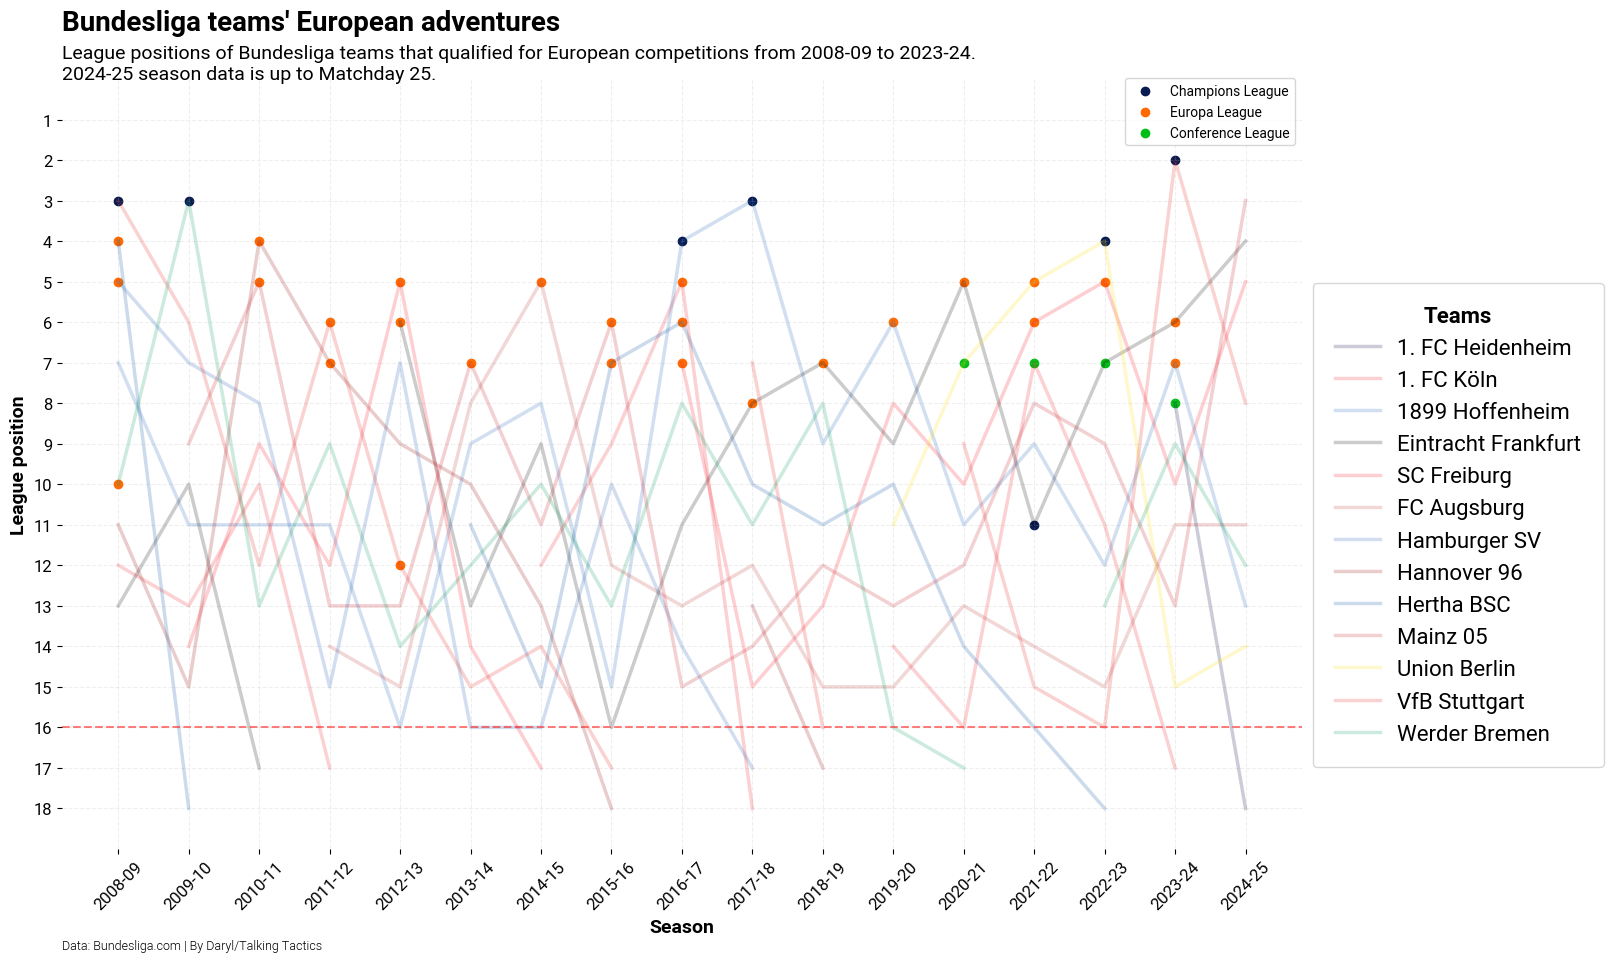

In [197]:
# Plot a line graph
fig, ax = plt.subplots(figsize=(16, 10))

# Plot the lines
for team in europe_matrix.index:
    if team == "1. FC Heidenheim":
        heidenheim = plot_line(ax, team, "#000040", team)
    elif team == "1. FC Köln":
        koln = plot_line(ax, team, "#ED1C24", team)
    elif team == "1899 Hoffenheim":
        hoffenheim = plot_line(ax, team, "#1961B5", team)
    elif team == "Eintracht Frankfurt":
        frankfurt = plot_line(ax, team, "#000000", team)
    elif team == "SC Freiburg":
        freiburg = plot_line(ax, team, "#fd1220", team)
    elif team == "FC Augsburg":
        augsburg = plot_line(ax, team, "#BA3733", team)
    elif team == "Hamburger SV":
        hamburg = plot_line(ax, team, "#1E5CB3", team)
    elif team == "Hannover 96":
        hannover = plot_line(ax, team, "#930000", team)
    elif team == "Hertha BSC":
        hertha = plot_line(ax, team, "#004D9E", team)
    elif team == "Mainz 05":
        mainz = plot_line(ax, team, "#C3141E", team)
    elif team == "Union Berlin":
        unionB = plot_line(ax, team, "#FDDC02", team)
    elif team == "VfB Stuttgart":
        stuttgart = plot_line(ax, team, "#E32219", team)
    elif team == "Werder Bremen":
        bremen = plot_line(ax, team, "#009655", team)

# Add scatter points for Champions League positions
# (top 3 until 2010-11, top 4 until 2022-23, top 5 from 2023-24)
for team in europe_matrix.index:
    for season in europe_matrix.columns:
        if pd.notnull(europe_matrix.at[team, season]):
            # Top 3 until 2010-11
            if (season in ["2008-09", "2009-10", "2010-11"]) & (
                europe_matrix.at[team, season] == 1
                or europe_matrix.at[team, season] == 2
                or europe_matrix.at[team, season] == 3
            ):
                ucl = plot_scatter(ax, season, team, "Champions League")
            # Special case for Frankfurt's 2021-22 season
            elif (
                season
                in [
                    "2021-22",
                ]
            ) & (europe_matrix.at[team, season] == 11):
                ucl = plot_scatter(ax, season, team, "Champions League")
            # Top 4 until 2022-23
            elif (
                season
                in [
                    "2011-12",
                    "2012-13",
                    "2013-14",
                    "2014-15",
                    "2015-16",
                    "2016-17",
                    "2017-18",
                    "2018-19",
                    "2019-20",
                    "2020-21",
                    "2021-22",
                    "2022-23",
                ]
            ) & (
                europe_matrix.at[team, season] == 1
                or europe_matrix.at[team, season] == 2
                or europe_matrix.at[team, season] == 3
                or europe_matrix.at[team, season] == 4
            ):
                ucl = plot_scatter(ax, season, team, "Champions League")
            # Top 5 from 2023-24
            elif (season in ["2023-24"]) & (
                europe_matrix.at[team, season] == 1
                or europe_matrix.at[team, season] == 2
                or europe_matrix.at[team, season] == 3
                or europe_matrix.at[team, season] == 4
                or europe_matrix.at[team, season] == 5
            ):
                ucl = plot_scatter(ax, season, team, "Champions League")

# Add scatter points for Europa League positions
for team in europe_matrix.index:
    for season in europe_matrix.columns:
        if pd.notnull(europe_matrix.at[team, season]):
            # Special cases
            if (season in ["2008-09"]) & (europe_matrix.at[team, season] == 10):
                uel = plot_scatter(ax, season, team, "Europa League")
            elif (season in ["2010-11"]) & (europe_matrix.at[team, season] == 14):
                uel = plot_scatter(ax, season, team, "Europa League")
            elif (season in ["2012-13"]) & (europe_matrix.at[team, season] == 12):
                uel = plot_scatter(ax, season, team, "Europa League")
            elif (season in ["2017-18"]) & (europe_matrix.at[team, season] == 8):
                uel = plot_scatter(ax, season, team, "Europa League")
            # General cases
            # 4th & 5th until 2010-11
            elif (season in ["2008-09", "2009-10", "2010-11"]) & (
                europe_matrix.at[team, season] == 4
                or europe_matrix.at[team, season] == 5
            ):
                uel = plot_scatter(ax, season, team, "Europa League")
            # 5th & 6th until 2022-23
            elif (
                season
                in [
                    "2009-10" "2011-12",
                    "2012-13",
                    "2013-14",
                    "2014-15",
                    "2015-16",
                    "2016-17",
                    "2017-18",
                    "2018-19",
                    "2019-20",
                    "2020-21",
                    "2021-22",
                    "2022-23",
                ]
            ) & (
                europe_matrix.at[team, season] == 5
                or europe_matrix.at[team, season] == 6
            ):
                uel = plot_scatter(ax, season, team, "Europa League")
            # 6th & 7th from 2023-24
            elif (
                season
                in [
                    "2011-12",
                    "2013-14",
                    "2014-15",
                    "2015-16",
                    "2016-17",
                    "2018-19",
                    "2019-20",
                    "2023-24",
                ]
            ) & (
                europe_matrix.at[team, season] == 6
                or europe_matrix.at[team, season] == 7
            ):
                uel = plot_scatter(ax, season, team, "Europa League")

# Add scatter points for Europa Conference League positions
for team in europe_matrix.index:
    for season in europe_matrix.columns:
        if pd.notnull(europe_matrix.at[team, season]):
            # 7th from 2020-21
            if (season in ["2020-21", "2021-22", "2022-23"]) & (
                europe_matrix.at[team, season] == 7
            ):
                uecl = plot_scatter(ax, season, team, "Conference League")
            # 8th in 2023-24
            elif (season in ["2023-24"]) & (europe_matrix.at[team, season] == 8):
                uecl = plot_scatter(ax, season, team, "Conference League")

# Add legend
scatter_legend = ax.legend(
    [ucl, uel, uecl],
    ["Champions League", "Europa League", "Conference League"],
    bbox_to_anchor=(1, 1.01),
    prop=robotoRegular,
    fontsize=8,
)
ax.add_artist(scatter_legend)

# Create a legend for the lines
ax.legend(
    [
        heidenheim[0],
        koln[0],
        hoffenheim[0],
        frankfurt[0],
        freiburg[0],
        augsburg[0],
        hamburg[0],
        hannover[0],
        hertha[0],
        mainz[0],
        unionB[0],
        stuttgart[0],
        bremen[0],
    ],
    [
        "1. FC Heidenheim",
        "1. FC Köln",
        "1899 Hoffenheim",
        "Eintracht Frankfurt",
        "SC Freiburg",
        "FC Augsburg",
        "Hamburger SV",
        "Hannover 96",
        "Hertha BSC",
        "Mainz 05",
        "Union Berlin",
        "VfB Stuttgart",
        "Werder Bremen",
    ],
    title="Teams",
    title_fontproperties={"family": "Roboto", "weight": "bold", "size": 16},
    bbox_to_anchor=(1, 0.75),
    prop={
        "family": "Roboto",
        "weight": "normal",
        "size": 16,
    },
    fontsize="large",
    borderpad=1,
)

# Flip the y-axis
ax.invert_yaxis()

# Modify y-axis
ax.set_ylim(19, 0)
ax.set_yticks(np.arange(1, 19, 1))

# Modify tick labels
ax.set_yticklabels(np.arange(1, 19, 1), fontproperties=robotoRegular, fontsize=12)
ax.set_xticklabels(
    europe_matrix.columns.to_list(),
    fontproperties=robotoRegular,
    fontsize=12,
    rotation=45,
)

# Add axis labels
ax.set_xlabel("Season", fontproperties=robotoBold, fontsize=14)
ax.set_ylabel("League position", fontproperties=robotoBold, fontsize=14)

# Add grid
ax.grid(axis="y", linestyle="--", which="major", alpha=0.2)
ax.grid(axis="x", linestyle="--", which="major", alpha=0.2)

# Remove spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Draw a line at 16th position
ax.axhline(y=16, color="red", linestyle="--", alpha=0.5)

# Add title
fig.suptitle(
    "Bundesliga teams' European adventures",
    fontproperties=robotoBold,
    fontsize=20,
    x=0.125,
    y=0.95,
    ha="left",
)
# Add subtitle
fig.text(
    0.125,
    0.88,
    "League positions of Bundesliga teams that qualified for European competitions from 2008-09 to 2023-24.\n2024-25 season data is up to Matchday 25.",
    fontproperties=robotoRegular,
    fontsize=14,
    ha="left",
)
# Add footer
fig.text(
    0.125,
    0.01,
    "Data: Bundesliga.com | By Daryl/Talking Tactics",
    fontproperties=robotoLight,
    fontsize=9,
    ha="left",
)